# Notebook 2: ML Environment Wrapper Development

**Goal:** Implement and test the `GreenhouseEnv` class, ensuring it conforms to the Gymnasium API and correctly interacts with the simulator.

## 1. Setup and Imports

Import Gymnasium, Stable Baselines3 utilities, NumPy, and our custom modules.

In [1]:
import sys
import os
import yaml
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import random
import matplotlib.pyplot as plt
import seaborn as sns

# --- Add project root to sys.path ---
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"Added '{project_root}' to sys.path")

# --- Import project modules ---
try:
    # Import the environment wrapper itself
    from ml_training.custom_env_wrapper import GreenhouseEnv, OBSERVATION_FEATURE_ORDER, OBS_DIM, ACTION_DIM, OBS_LOW, OBS_HIGH
    # Import simulator core for potential direct use if needed for testing
    from simulator.core import GreenhouseSimulator, SensorSnapshot, ControlState
    # Import checker utility
    from stable_baselines3.common.env_checker import check_env
    print("Successfully imported project modules and checker.")
except ImportError as e:
    print(f"ERROR: Failed to import modules: {e}")
    print("Ensure you have run Notebook 01 and created necessary files.")
    print("Make sure stable_baselines3 and gymnasium are installed.")

# --- Plotting Style ---
sns.set_theme(style="ticks", context="notebook")

Successfully imported project modules and checker.


## 2. Environment Configuration

Define the parameters needed to initialize the environment, such as the city config path and target ranges.

In [2]:
# --- Configuration for Testing ---
CITY = 'oslo' # or 'riyadh'
MODE = 'normal' # or 'eco'
DT_MIN_ENV = 5 # Should match the value used in the wrapper's default or init
MAX_DAYS_ENV = 3 # Use a short duration for testing

city_config_path = os.path.join(project_root, 'simulator', 'city_configs', f'{CITY}.yaml')

# Load default targets from city config for testing
try:
    with open(city_config_path, 'r') as f:
        city_config = yaml.safe_load(f)
    TARGET_RANGES = {k.replace('default_target_',''): v for k, v in city_config.items() if k.startswith('default_target_')}
    print(f"Using target ranges for {CITY.capitalize()}: {TARGET_RANGES}")
except Exception as e:
    print(f"ERROR loading city config {city_config_path}: {e}")
    # Define dummy targets if loading fails, but tests might be invalid
    TARGET_RANGES = {'t_c_min': 18, 't_c_max': 22, 'rh_min': 50, 'rh_max': 70, 'sm_min': 40, 'sm_max': 60}

Using target ranges for Oslo: {'t_c_min': 16.0, 't_c_max': 20.0, 'rh_min': 65.0, 'rh_max': 75.0, 'sm_min': 50.0, 'sm_max': 65.0}


## 3. Instantiate and Check Environment

Create an instance of `GreenhouseEnv` and use the Stable Baselines3 `check_env` utility to verify its compliance with the Gymnasium API.

In [3]:
print("--- Instantiating Environment ---")
env = None # Initialize env to None outside the try block
check_env_passed = False # Initialize flag
try:
    # --- Instantiate Environment ---
    env = GreenhouseEnv(
        city_config_path=city_config_path,
        target_ranges=TARGET_RANGES,
        mode=MODE,
        dt_min=DT_MIN_ENV,
        max_days=MAX_DAYS_ENV
    )
    print("Environment instantiated successfully.")

    # --- Check Environment Compliance (only if instantiation succeeded) ---
    print("\n--- Running Environment Checker ---")
    try:
        # Use the official checker
        from stable_baselines3.common.env_checker import check_env
        check_env(env, warn=True)
        check_env_passed = True # Set flag to True if check_env completes without error
        print("\n✅ check_env completed without raising exceptions.")
    except Exception as e_check:
        print(f"\nERROR during environment check: {e_check}")
        import traceback
        traceback.print_exc()
        # check_env_passed remains False

except FileNotFoundError as e_file:
    print(f"\nERROR: Config file not found during environment instantiation: {e_file}")
    # env remains None
except Exception as e_init:
    print(f"\nERROR during environment instantiation: {e_init}")
    import traceback
    traceback.print_exc()
    # env remains None

# Optional: Print final status
if env is not None:
    print("\nEnvironment object created.")
else:
    print("\nEnvironment object creation failed.")

--- Instantiating Environment ---
GreenhouseEnv initialized: oslo.yaml, Mode: normal, Max Steps: 864
Environment instantiated successfully.

--- Running Environment Checker ---

✅ check_env completed without raising exceptions.

Environment object created.


## 4. Test Core Methods (`reset`, `step`)

Manually call `reset` and `step` to ensure they return values with the correct types and shapes, and that the simulation progresses.

In [4]:
print("\n--- Testing reset() ---")
try:
    observation, info = env.reset(seed=42) # Use a seed for reproducibility
    print(f"Reset successful.")
    print(f"Initial Observation Shape: {observation.shape}")
    print(f"Initial Observation Type: {type(observation)}")
    print(f"Initial Observation Dtype: {observation.dtype}")
    print(f"Info dictionary: {info}")
    # Verify shape matches defined space
    assert observation.shape == env.observation_space.shape, "Observation shape mismatch!"
    # Verify observation is within bounds
    assert env.observation_space.contains(observation), "Initial observation out of bounds!"

except Exception as e:
    print(f"ERROR during env.reset(): {e}")
    import traceback
    traceback.print_exc()

print("\n--- Testing step() with Random Actions ---")
rewards = []
n_test_steps = 10
terminated = False
truncated = False
current_step = 0
step_test_completed = False # Define variable before loop

if 'env' in locals() and hasattr(env, 'step'): # Check if env was created
    print(f"Running {n_test_steps} steps...")
    try: # Wrap the loop in try/except
        for i in range(n_test_steps):
            if terminated or truncated:
                print(f"Episode ended early at step {i}.")
                break
            # Sample a random action
            action = env.action_space.sample()
            print(f" Step {i+1}: Taking action {action}")

            observation, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            current_step += 1

            # Basic checks
            assert env.observation_space.contains(observation), f"Observation out of bounds at step {i+1}!"
            assert isinstance(reward, float), "Reward is not a float!"
            assert isinstance(terminated, bool), "Terminated is not a bool!"
            assert isinstance(truncated, bool), "Truncated is not a bool!"
            assert isinstance(info, dict), "Info is not a dict!"

        print(f"\nFinished {current_step} steps successfully.")
        step_test_completed = True # Set flag to True if loop completes

    except Exception as e:
        print(f"ERROR during env.step() test at step {i+1 if 'i' in locals() else 0}: {e}")
        import traceback
        traceback.print_exc()
        # step_test_completed remains False

    if rewards:
        print(f"Sample Rewards: {rewards}")
        print(f"Average Reward: {np.mean(rewards):.3f}")
else:
    print("Skipping step test as environment was not successfully created.")

# --- Close the environment ---
if 'env' in locals() and hasattr(env, 'close'):
    env.close()
    print("\nEnvironment closed.")


--- Testing reset() ---
Reset successful.
Initial Observation Shape: (19,)
Initial Observation Type: <class 'numpy.ndarray'>
Initial Observation Dtype: float32
Info dictionary: {}

--- Testing step() with Random Actions ---
Running 10 steps...
 Step 1: Taking action 3
 Step 2: Taking action 19
 Step 3: Taking action 10
 Step 4: Taking action 1
 Step 5: Taking action 8
 Step 6: Taking action 18
 Step 7: Taking action 3
 Step 8: Taking action 4
 Step 9: Taking action 15
 Step 10: Taking action 8

Finished 10 steps successfully.
Sample Rewards: [-0.05025, -0.054000000000000006, -0.00375, -1.5640558704227288, -1.3051350559718895, -2.045718974502112, -9.772851445013634, -27.48028979237317, -41.19471951166193, -32.43134053920791]
Average Reward: -11.590

Environment closed.


## 5. Visualize Observation Space (Optional)

Plot the defined bounds for each feature in the observation space to visually check if they seem reasonable.


--- Visualizing Observation Space Bounds ---


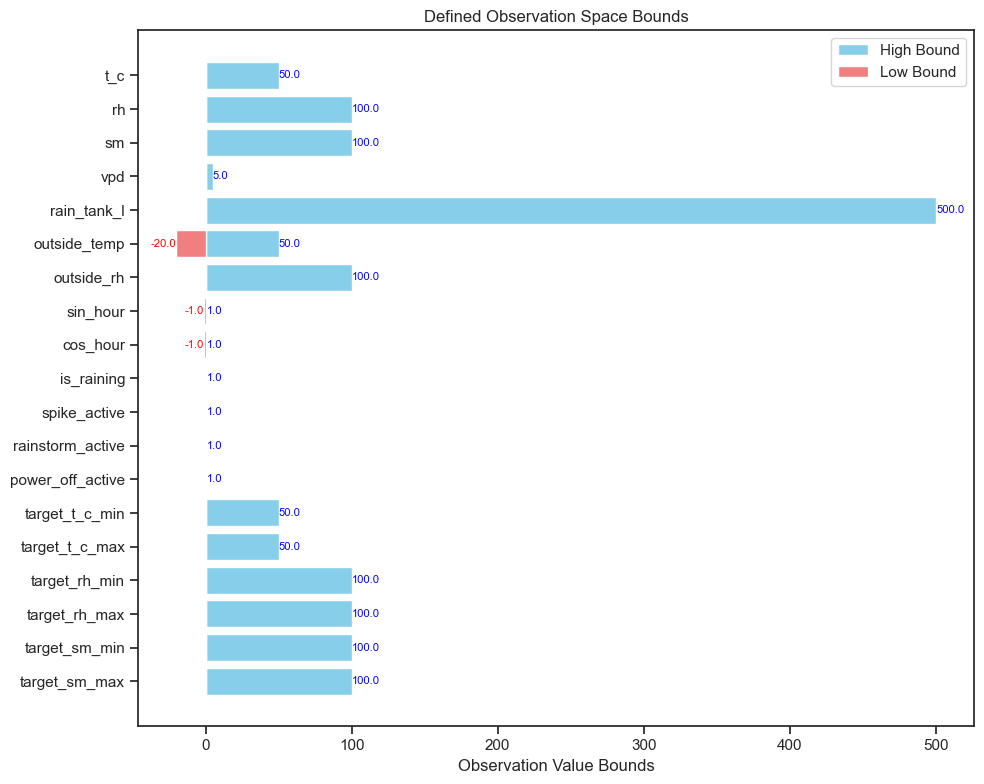

In [5]:
print("\n--- Visualizing Observation Space Bounds ---")
try:
    feature_names = OBSERVATION_FEATURE_ORDER
    low_bounds = env.observation_space.low
    high_bounds = env.observation_space.high

    plt.figure(figsize=(10, 8))
    plt.barh(feature_names, high_bounds, color='skyblue', label='High Bound')
    plt.barh(feature_names, low_bounds, color='lightcoral', label='Low Bound') # Low bounds might be negative or zero

    # Add text labels for bounds
    for i, (low, high) in enumerate(zip(low_bounds, high_bounds)):
         # Adjust text position slightly for clarity
         plt.text(high + 0.1, i, f'{high:.1f}', va='center', color='blue', fontsize=8)
         if low != 0: # Only show low bound if not zero
             plt.text(low - 0.1, i, f'{low:.1f}', va='center', ha='right', color='red', fontsize=8)

    plt.xlabel("Observation Value Bounds")
    plt.title("Defined Observation Space Bounds")
    plt.legend()
    plt.gca().invert_yaxis() # Display features top-to-bottom
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not visualize observation space: {e}")


## 6. Conclusion

This notebook successfully instantiated the `GreenhouseEnv` wrapper. The `check_env` utility confirmed basic API compliance. Manual calls to `reset` and `step` produced outputs of the correct type and shape, and the observation space bounds were visualized. The environment appears ready for use in training the PPO agent in the next notebook.

In [6]:
# --- Notebook 02 Diagnostics Cell ---
import pandas as pd
import numpy as np
from datetime import datetime
import traceback

print("--- Notebook 02 Diagnostics ---")
print(f"Timestamp: {datetime.now()}")

# Check if environment was instantiated
env_created = False
env_obs_space = "N/A"
env_act_space = "N/A"
try:
    if 'env' in locals() and env is not None and hasattr(env, 'observation_space') and hasattr(env, 'action_space'):
        env_created = True
        env_obs_space = str(env.observation_space)
        env_act_space = str(env.action_space)
except Exception as e:
    print(f"WARN: Error accessing env object: {e}")

print(f"\nEnvironment Instantiation:")
print(f"- GreenhouseEnv Instantiated: {env_created}")
if env_created:
    print(f"- Observation Space: {env_obs_space}")
    print(f"- Action Space: {env_act_space}")

# Check check_env result (relies on flag set in the check_env cell)
check_env_status = "Check Not Performed or Variable 'check_env_passed' not set"
try:
    if 'check_env_passed' in locals():
        check_env_status = "Passed" if check_env_passed else "Failed"
    elif env_created:
        check_env_status = "Check Not Performed in this session"
    else:
        check_env_status = "N/A (Env not created)"
except NameError:
    pass # Variable not defined, keep default status
print(f"\nStable Baselines3 check_env Status: {check_env_status}")


# Check reset/step test result (relies on flag set in the step test cell)
step_test_status = "Tests Not Performed or Variable 'step_test_completed' not set"
avg_reward_info = "N/A"
try:
    if 'step_test_completed' in locals():
        step_test_status = "Completed" if step_test_completed else "Failed or Not Run"
        if 'rewards' in locals() and rewards:
            avg_reward_info = f"{np.mean(rewards):.3f} (from {len(rewards)} steps)"
        else:
            avg_reward_info = "(No rewards list found)"
    elif env_created:
         step_test_status = "Tests Not Performed in this session"
    else:
         step_test_status = "N/A (Env not created)"
except NameError:
     pass # Variable not defined

print(f"\nManual Reset/Step Tests Status: {step_test_status}")
print(f"- Sample Avg Reward from Test: {avg_reward_info}")


print("\n--- End Notebook 02 Diagnostics ---")

--- Notebook 02 Diagnostics ---
Timestamp: 2025-05-06 20:08:46.421847

Environment Instantiation:
- GreenhouseEnv Instantiated: True
- Observation Space: Box([  0.   0.   0.   0.   0. -20.   0.  -1.  -1.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.], [ 50. 100. 100.   5. 500.  50. 100.   1.   1.   1.   1.   1.   1.  50.
  50. 100. 100. 100. 100.], (19,), float32)
- Action Space: Discrete(24)

Stable Baselines3 check_env Status: Passed

Manual Reset/Step Tests Status: Completed
- Sample Avg Reward from Test: -11.590 (from 10 steps)

--- End Notebook 02 Diagnostics ---
